In [1]:
print("Hello")

Hello


In [2]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device(drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
) 

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:4', 'NVIDIA A100-SXM4-80GB', 49432)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 49420)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 48696)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 48696)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 46348)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 33536)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 28416)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 17022)

# #### Device() ####
# device = cuda:5

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:5)
# edge_attr                (32464, 16)              Tensor (cuda:5)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:5)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

---

In [3]:
import pandas as pd

In [4]:
gene_names = dataset.wrapper.x_labels
num_genes = len(gene_names)
X = _batch.x.view(-1, num_genes)

In [7]:
df = pd.DataFrame(X.cpu().numpy().T, index=gene_names)
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
FGR,2221.0,343.0,286.0,1002.0,501.0,308.0,497.0,720.0,551.0,230.0,...,360.0,439.0,1585.0,489.0,332.0,540.0,869.0,1039.0,76.0,1145.0
GCLC,1604.0,2069.0,555.0,2752.0,1299.0,2829.0,986.0,1942.0,1355.0,4176.0,...,8433.0,3137.0,2150.0,1421.0,4724.0,1123.0,2077.0,1367.0,1025.0,2817.0
NFYA,3821.0,2986.0,955.0,2326.0,8584.0,5202.0,1871.0,1540.0,3079.0,3441.0,...,7615.0,3630.0,3226.0,8208.0,8322.0,1585.0,3469.0,1768.0,1602.0,5877.0
SEMA3F,4137.0,3947.0,3413.0,7930.0,3472.0,5402.0,6026.0,6870.0,8946.0,9864.0,...,10091.0,3361.0,4397.0,2315.0,8224.0,8537.0,3815.0,8128.0,26163.0,11062.0
CFTR,19.0,43.0,6.0,63.0,8.0,202.0,1.0,15.0,55.0,8.0,...,186.0,77.0,24.0,28.0,15.0,23.0,79.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF229,483.0,940.0,146.0,109.0,23.0,443.0,95.0,32.0,826.0,1150.0,...,1796.0,1011.0,244.0,445.0,61.0,206.0,535.0,1238.0,268.0,332.0
ACACA,5338.0,14836.0,1793.0,5652.0,3788.0,17320.0,5953.0,8223.0,26732.0,11656.0,...,16016.0,8574.0,9461.0,7823.0,27938.0,10665.0,4959.0,2701.0,2874.0,47236.0
H3C10,217.0,36.0,75.0,107.0,16.0,71.0,24.0,2706.0,418.0,2890.0,...,53.0,44.0,353.0,1484.0,95.0,3976.0,2529.0,66.0,3265.0,1851.0
ADORA3,248.0,139.0,49.0,311.0,166.0,301.0,377.0,632.0,97.0,253.0,...,647.0,313.0,413.0,65.0,496.0,568.0,1027.0,341.0,96.0,641.0


In [6]:
pathway_idx = dataset.wrapper.pathway_index
pathway_names = dataset.wrapper.pathway_labels

gene_sets = {}

for p, pathway in enumerate(pathway_names):
    genes = [gene_names[g] for g in range(num_genes) if pathway_idx[g, p] == 1]
    gene_sets[pathway] = genes

KeyboardInterrupt: 

---

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import gseapy as gp
import numpy as np

In [ ]:
ssgsea = gp.ssgsea(data=df, gene_sets=gene_sets, outdir=None)
gsva = gp.gsva(data=df, gene_sets=gene_sets, outdir=None)

2026-05-03 09:54:50,413 [WARNING] Found duplicated gene names, values averaged by gene names!
2026-05-03 09:54:51,987 [WARNING] Found duplicated gene names, values averaged by gene names!


ssGSEA (gene set enrichment analysis)
* are genes in pathway consistently (& highly) expressed within this sample vs. others
* rank genes by expression -> sum(Phit - Pmiss)
* pos=highly expressed, 0=not enriched, neg=lowly expressed

GSVA (gene set variation analysis)
* variation across samples

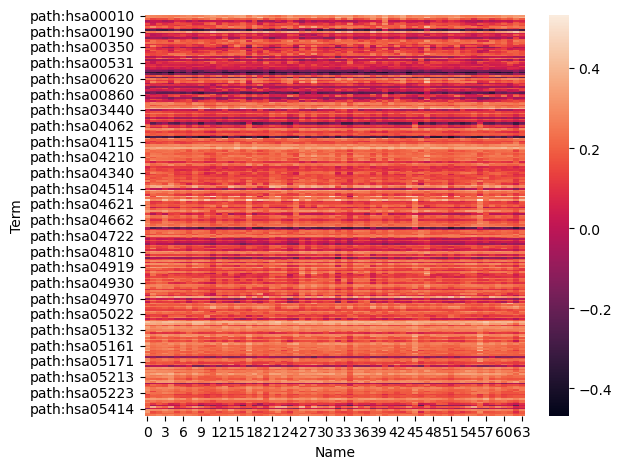

In [ ]:
mat = ssgsea.res2d.pivot(index="Term", columns="Name", values="NES")
mat = mat.apply(pd.to_numeric, errors="coerce")

sns.heatmap(mat)
plt.tight_layout()
plt.show()

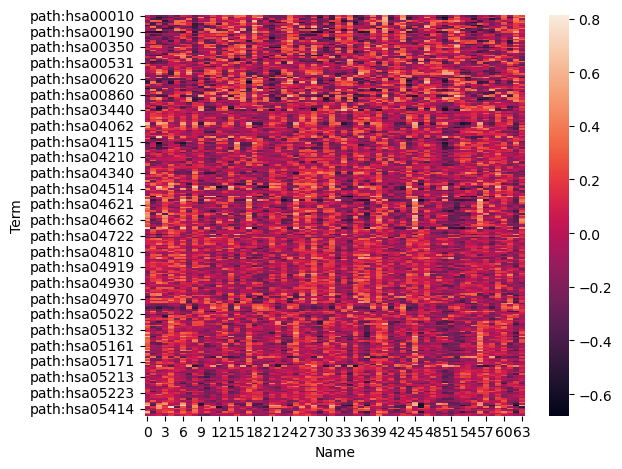

In [ ]:
mat = gsva.res2d.pivot(index="Term", columns="Name", values="ES")
mat = mat.apply(pd.to_numeric, errors="coerce")

sns.heatmap(mat)
plt.tight_layout()
plt.show()

---

In [ ]:
# load_model
from modules.train import Loader
from modules.data import GraphDataset
import torch

def load_model(model, state_dict_path:str, device:str, dataset:GraphDataset|None=None, batch_size:int=128):
    # init with loader
    init_fn = getattr(model, 'init_with_loader', None)
    if callable(init_fn) and dataset is not None:
        loader = Loader(dataset, device=device, batch_size=batch_size)
        init_fn(loader)

    # load state dict
    state_dict = torch.load(state_dict_path, map_location=device)
    model.load_state_dict(state_dict)

    # set model to eval
    model.eval()  

In [ ]:
# ModelOut
from torch_geometric.loader import DataLoader
from modules.data import GraphDataset
from modules.utils import dict_summary
from collections import defaultdict
# import pandas as pd

# typing
import torch
import torch.nn as nn
from torch import Tensor
from torch_geometric.data import Data, Batch

class ModelOut():
    def __init__(self, model:nn.Module, dataset:GraphDataset, batch_size:int=64, **fwd_kwargs):
        fwd_kwargs = fwd_kwargs if fwd_kwargs is not None else {}

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        x_list = []
        y_list = []
        out_list = []

        for batch in loader:
            out = model(batch, **fwd_kwargs)
            out = self._detach_items(out)
            out_list.append(out)
            x_list.append(batch.x)
            y_list.append(batch.y)

        self.x = torch.cat(x_list, dim=0).reshape(-1, dataset.wrapper.num_nodes).cpu()
        self.y = torch.cat(y_list, dim=0).cpu()
        self.out = self._transpose_values(out_list)

    def _detach_items(self, item):
        # single tensor
        if isinstance(item, Tensor):
            return item.detach().cpu()

        # list/tuple (recursive)
        if isinstance(item, (list, tuple, set)):
            return type(item)(self._detach_items(i) for i in item)

        # dict, PyG Data/DataBatch
        if isinstance(item, (dict, Data, Batch)):
            return {key: self._detach_items(value) for key, value in item.items()}
        
        # other class with .x
        if hasattr(item, 'x'):
            return {
                'x': self._detach_items(item.x),
                'y': self._detach_items(getattr(item, 'y', None)),
                'sample_id': self._detach_items(getattr(item, 'sample_id', None))
            }
        
        # fallback
        return item

    def _transpose_values(self, values) -> dict:
        out = defaultdict(list)

        # collect
        for v in values:
            for k, val in v.items():
                out[k].append(val)

        # concat if tensor
        for k, vals in out.items():
            v0 = vals[0]

            if torch.is_tensor(v0):
                if v0.ndim == 0: # scalar tensor -> stack
                    out[k] = torch.stack(vals, dim=0)

                # elif v0.ndim == 1: # vector tensor -> concat

                else: # batched tensor -> concat on batch dim
                    out[k] = torch.cat(vals, dim=0)
            
            elif isinstance(v0, dict): # dict -> recursively concat
                out[k] = self._transpose_values(vals)

            else:
                out[k] = vals

        return dict(out)  

In [ ]:
from modules.layers import AttentionSetPooling
from modules.model import MultiLatentModel
from modules.norm import LogCounts
import torch.nn as nn

# multihead model
model = MultiLatentModel(
    dataset = dataset,
    embed_dim = 128,
    # head_dim = None (default)
    # num_heads = 1 (default)
    method = 'set',

    # layers
    norm_class = LogCounts,
    encoder_class = nn.Linear,
    pooling_class = AttentionSetPooling,
    mlp = False,
    variational = True,
    # out_module = nn.Linear (default)

    # layer params
    hidden_dims = 1,
    act_fn = nn.ReLU, 
    norm_fn = 'layer', 
    end_fn = False,

    # kwargs
    norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True}
    # pooling_kwargs = None (default)
)

load_model(
    model=model,
    state_dict_path='output/2026-01-20_18h51m04s_benchmark_2_attn/pathway_vae/pathway_vae_trial_0_model.pth',
    device=device,
    dataset=dataset,
)

vals = ModelOut(model, dataset, need_weights=True)

---

In [ ]:
attn_np = vals.out['layer_outs']['np']['attn'] # (b,g,p)

# pathway attention (b,p)
attn_lp_ae = vals.out['layer_outs']['lp_ae']['attn'].squeeze()
attn_lp_cl = vals.out['layer_outs']['lp_cl']['attn'].squeeze()

# joint attention (b,g,p)
attn_joint_ae = attn_lp_ae.unsqueeze(1) * attn_np 
attn_joint_cl = attn_lp_cl.unsqueeze(1) * attn_np

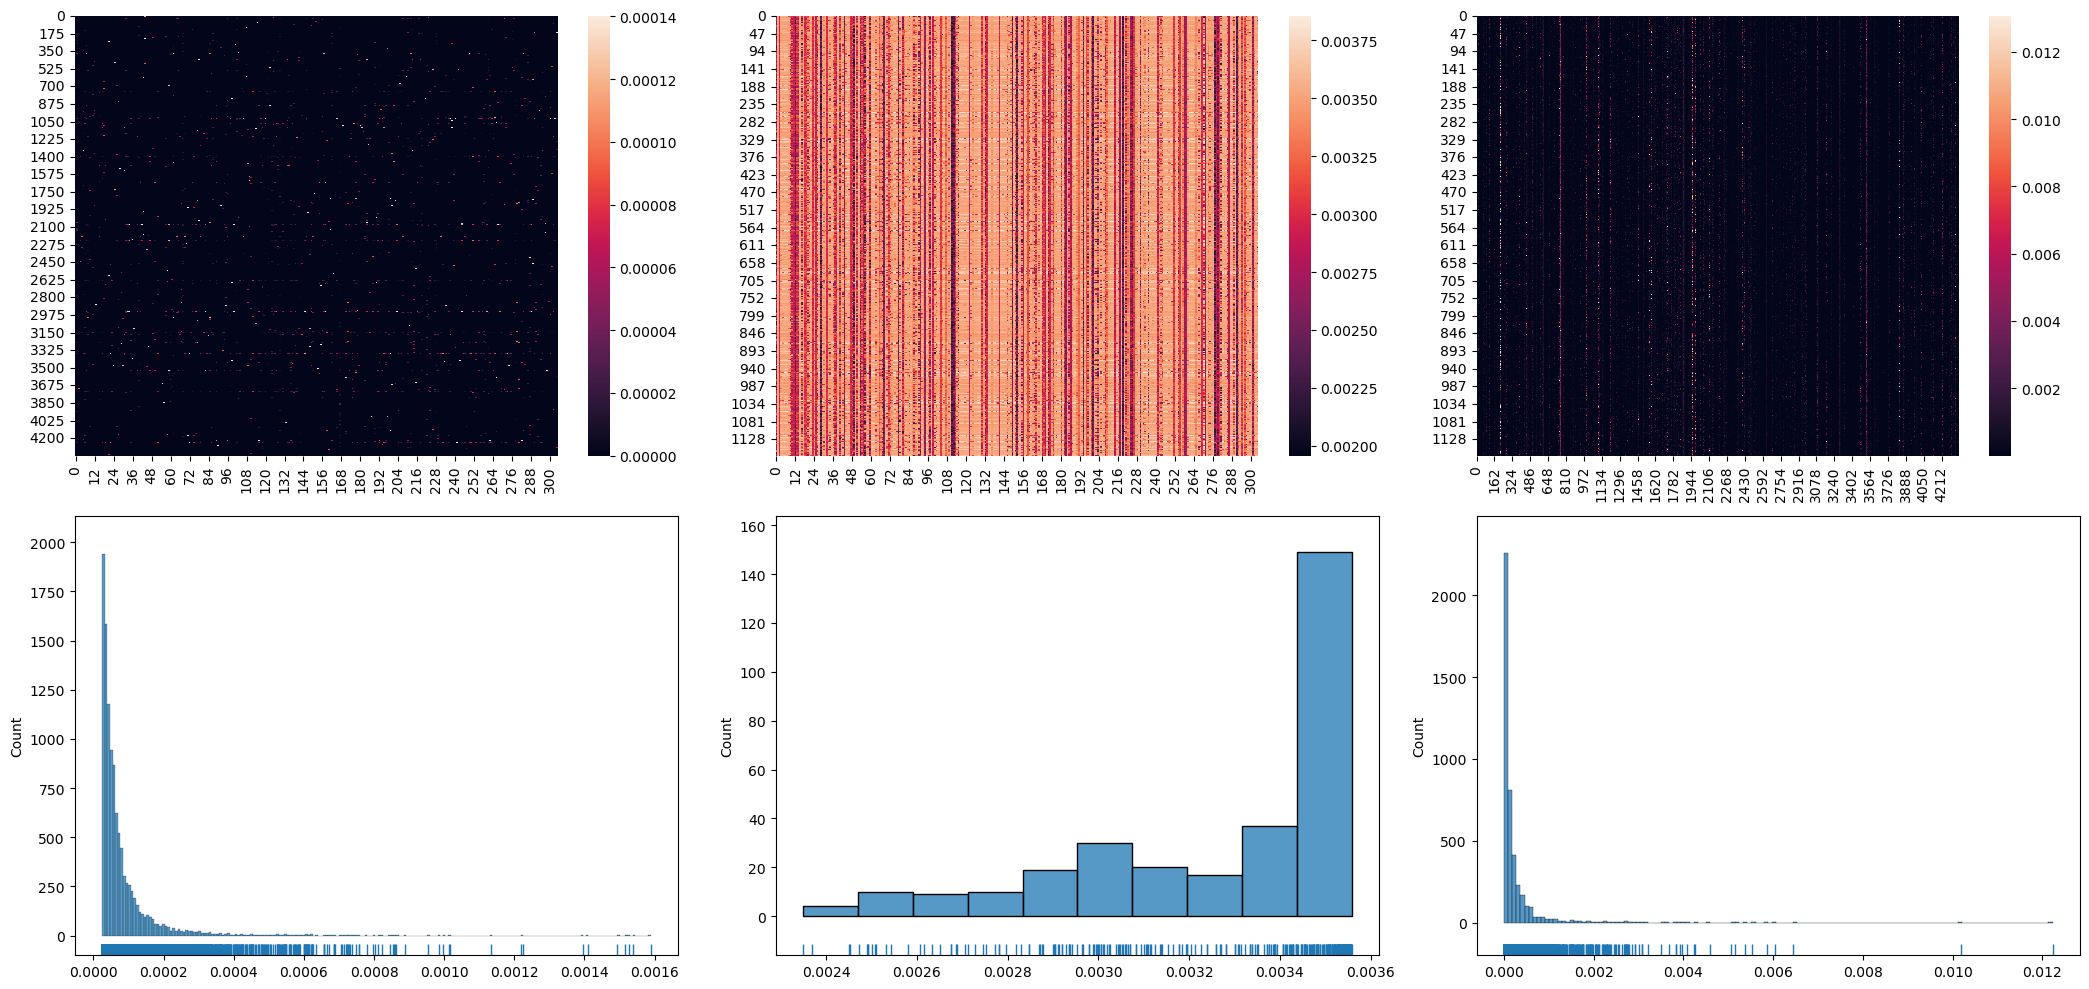

In [ ]:
# reconstruction joint attention
data = attn_joint_ae
alpha = 0.001
xmin=0

fig, ax = plt.subplots(2,3,figsize=(21,10))

x = data.mean(dim=0)
xmin = 0.000025
xflat = x.flatten()
xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,0])
sns.rugplot(xflat, ax=ax[1,0], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,0]).set(ylim=-100)

x = data.sum(dim=1)
xmin = 0.001
xflat = x.mean(dim=0).flatten()
# xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,1])
sns.rugplot(xflat, ax=ax[1,1], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,1]).set(ylim=-16)

x = data.sum(dim=2)
xmin = 0.005
xflat = x.mean(dim=0).flatten()
# xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,2])
sns.rugplot(xflat, ax=ax[1,2], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,2]).set(ylim=-200)

plt.tight_layout()
plt.show()


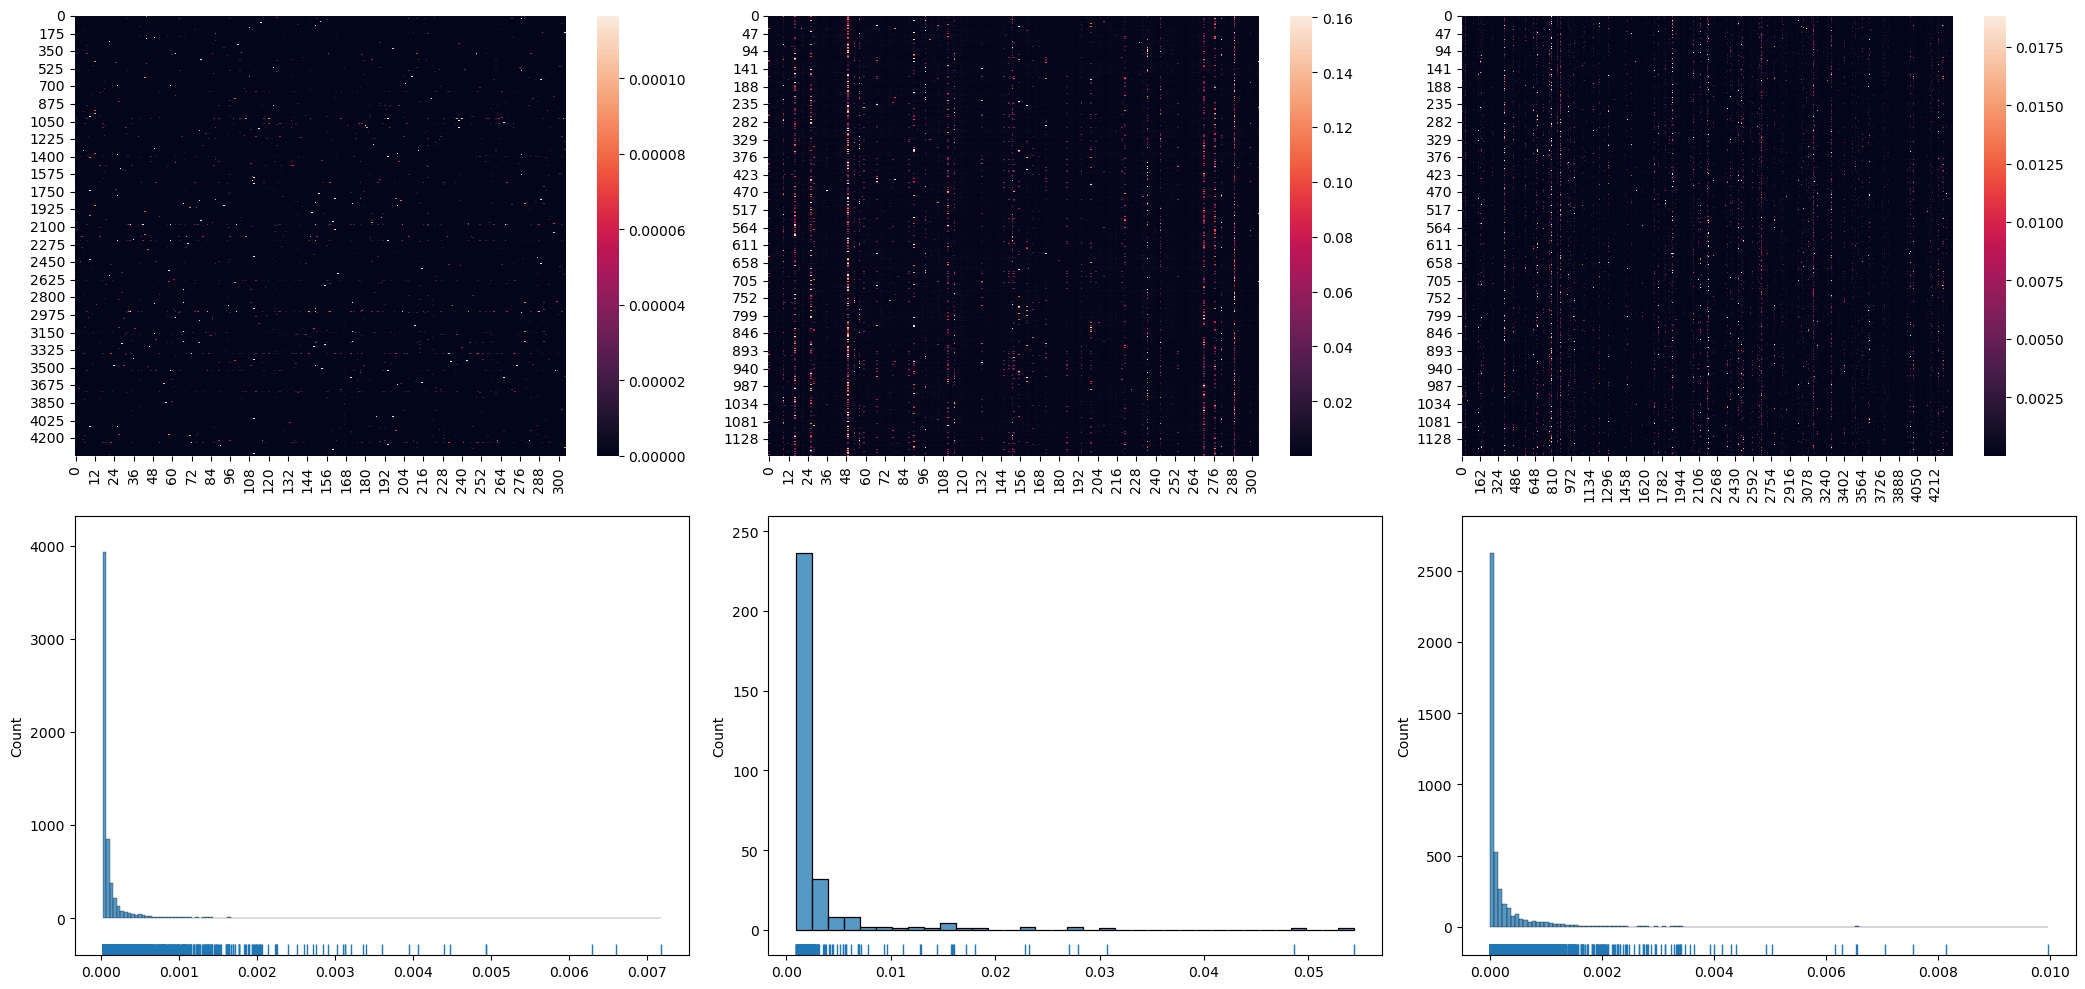

In [ ]:
# classification joint attention
data = attn_joint_cl
alpha = 0.001
xmin=0

fig, ax = plt.subplots(2,3,figsize=(21,10))

x = data.mean(dim=0)
xmin = 0.000025
xflat = x.flatten()
xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,0])
sns.rugplot(xflat, ax=ax[1,0], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,0]).set(ylim=-400)

x = data.sum(dim=1)
xmin = 0.001
xflat = x.mean(dim=0).flatten()
# xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,1])
sns.rugplot(xflat, ax=ax[1,1], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,1]).set(ylim=-16)

x = data.sum(dim=2)
xmin = 0.005
xflat = x.mean(dim=0).flatten()
# xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,2])
sns.rugplot(xflat, ax=ax[1,2], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,2]).set(ylim=-200)

plt.tight_layout()
plt.show()


---

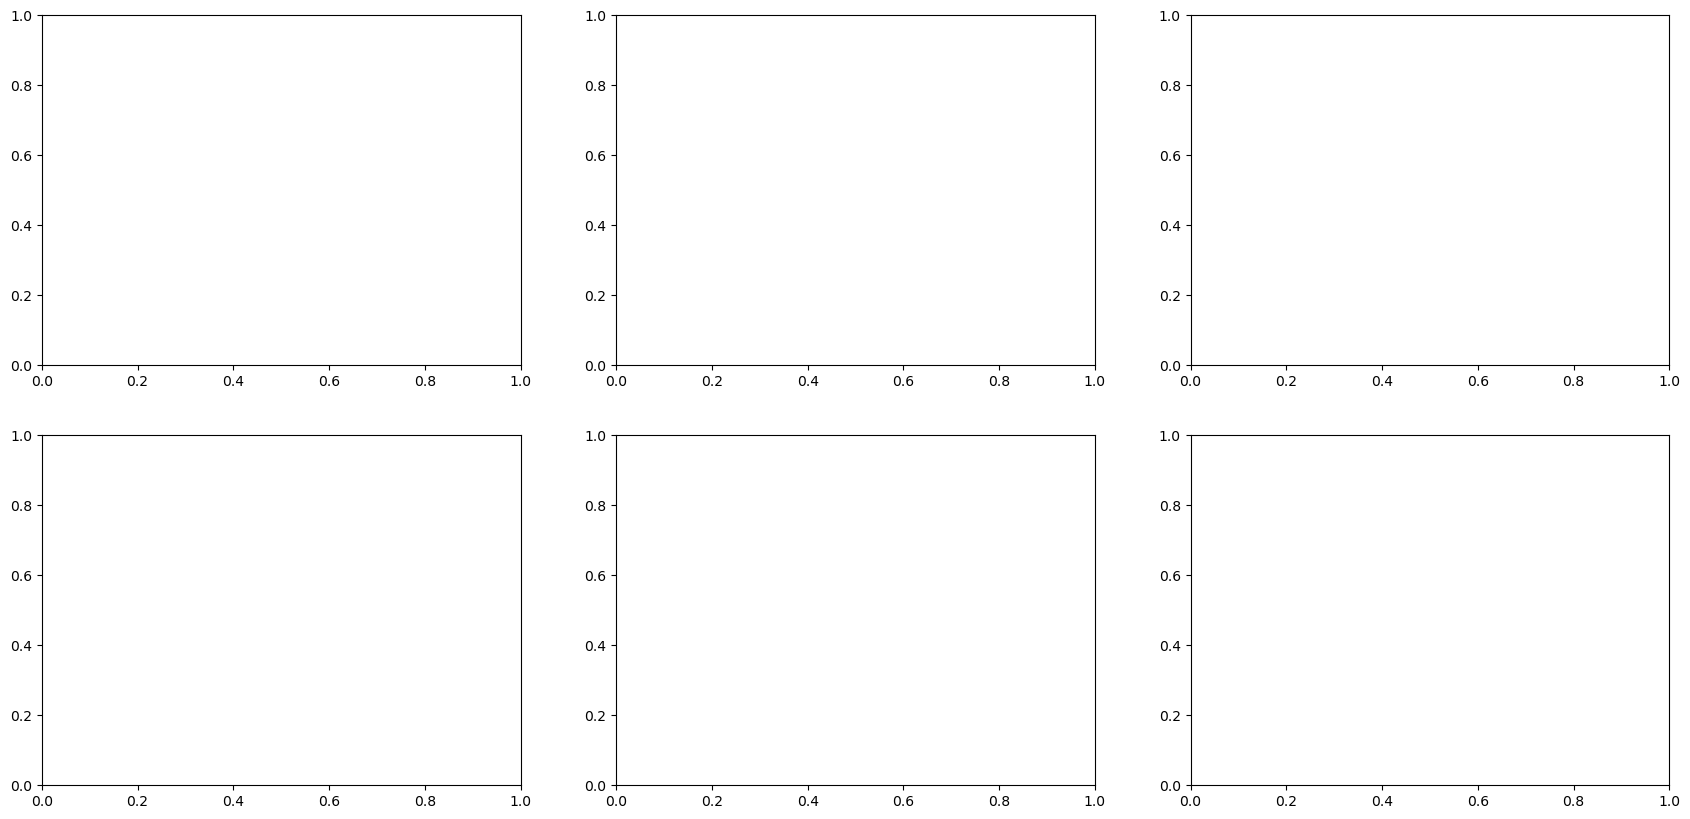

In [ ]:
fig, ax = plt.subplots(2,3,figsize=(21,10))

pathway_scores_ae = attn_joint_ae.sum(dim=1).mean(dim=0)
pathway_scores_cl = attn_joint_cl.sum(dim=1).mean(dim=0)

In [ ]:
pathway_scores_cl.shape

torch.Size([305])

In [ ]:
len(pathway_names)

305

In [ ]:
pathway_results = pd.DataFrame(
    {
        'name': pathway_names,
        'attn_ae': pathway_scores_ae.cpu().numpy(),
        'attn_cl': pathway_scores_cl.cpu().numpy(),
    }
)

ssgsea_results = (
    ssgsea.res2d.groupby('Term')[['ES','NES']].mean().reset_index()
    .rename(columns={'Term':'name', 'ES':'ssgsea_es','NES':'ssgsea_nes'})
)

gsva_results = (
    gsva.res2d.groupby('Term')['ES'].mean().reset_index()
    .rename(columns={'Term':'name', 'ES':'gsva_es'})
)

pathway_results['log_attn_ae'] = pathway_results['attn_ae'].apply(np.log10)
pathway_results['log_attn_cl'] = pathway_results['attn_cl'].apply(np.log10)
pathway_results = pd.merge(pathway_results, ssgsea_results, on='name')
pathway_results = pd.merge(pathway_results, gsva_results, on='name')
pathway_results

,name,attn_ae,attn_cl,log_attn_ae,log_attn_cl,ssgsea_es,ssgsea_nes,gsva_es
0,path:hsa04010,0.003528,0.001960,-2.452467,-2.707821,336.626204,0.119937,0.00763
1,path:hsa04630,0.002937,0.000972,-2.532120,-3.012159,767.80555,0.273564,-0.000333
2,path:hsa05030,0.003517,0.002123,-2.453767,-2.673032,359.651862,0.128141,0.013732
3,path:hsa05210,0.003525,0.001955,-2.452825,-2.708863,688.022599,0.245137,-0.017786
4,path:hsa04137,0.003554,0.002586,-2.449250,-2.587290,800.01546,0.28504,-0.034871
...,...,...,...,...,...,...,...,...
250,path:hsa04662,0.003522,0.001481,-2.453207,-2.829319,291.677163,0.103922,-0.005799
251,path:hsa00620,0.002752,0.001085,-2.560425,-2.964757,709.271081,0.252708,-0.037344
252,path:hsa04928,0.003428,0.001711,-2.464914,-2.766823,555.879526,0.198056,0.003667
253,path:hsa04922,0.003538,0.002074,-2.451233,-2.683173,650.032965,0.231602,0.002803


In [ ]:
print(f'E(x) = ',1/305)

E(x) =  0.003278688524590164


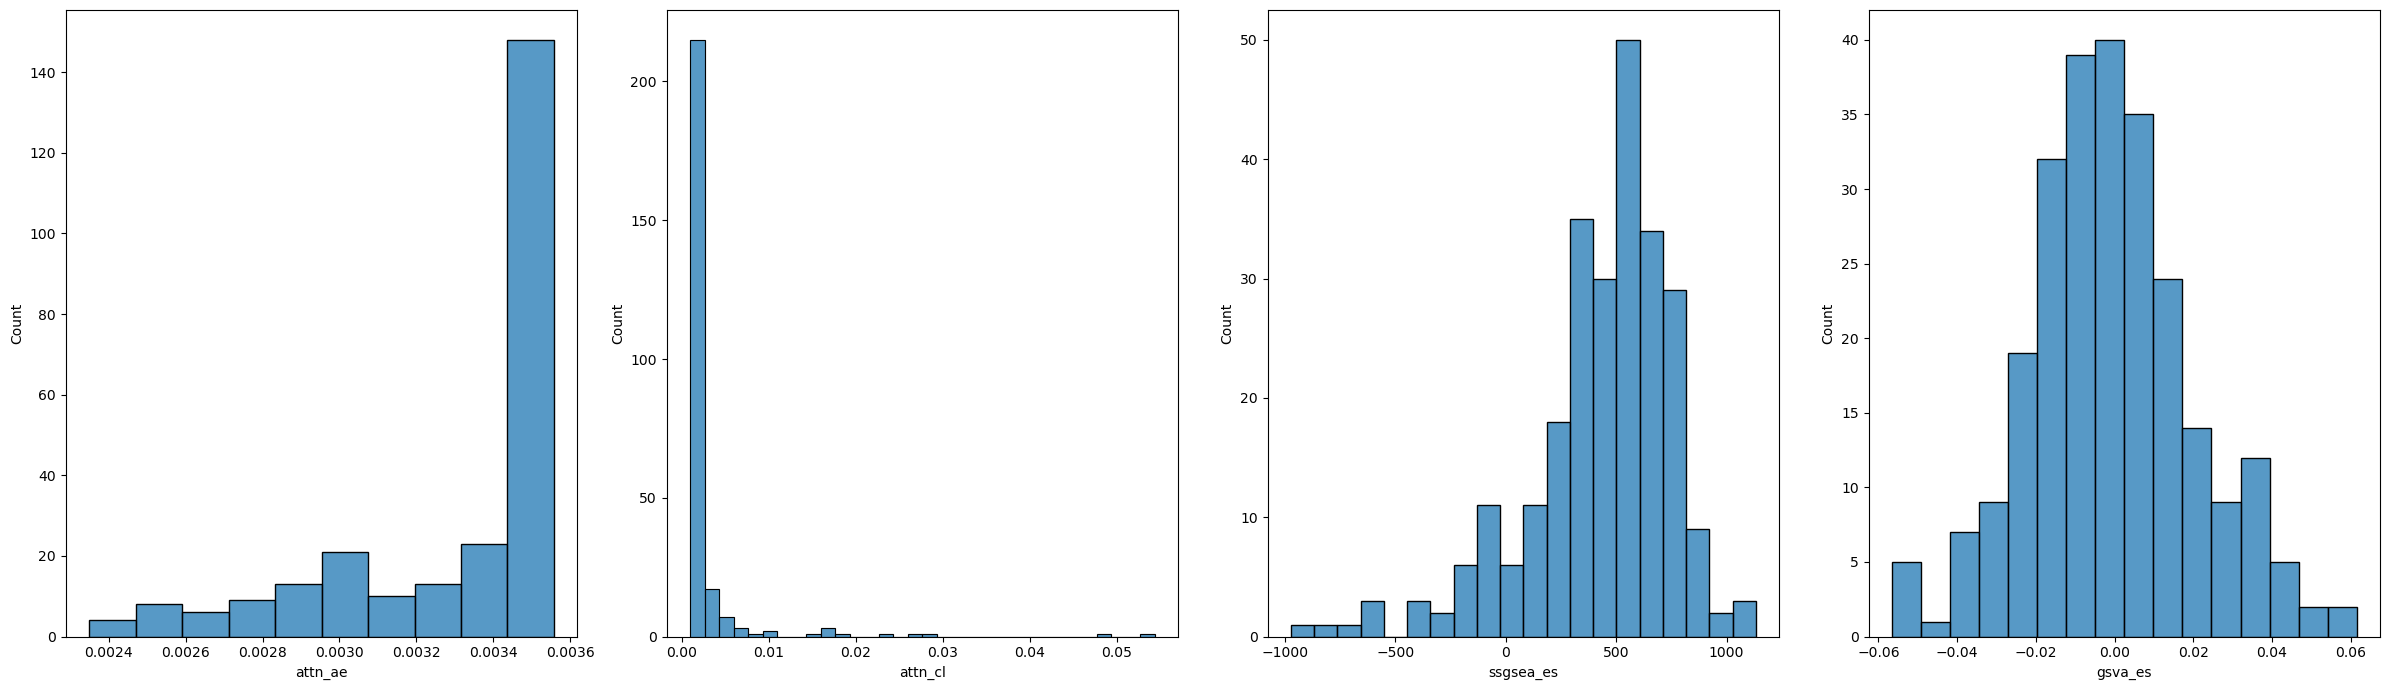

In [ ]:
fig, ax = plt.subplots(1,4,figsize=(24,7))

sns.histplot(pathway_results['attn_ae'], ax=ax[0])
sns.histplot(pathway_results['attn_cl'], ax=ax[1])
sns.histplot(pathway_results['ssgsea_es'], ax=ax[2])
sns.histplot(pathway_results['gsva_es'], ax=ax[3])

plt.tight_layout()
plt.show()

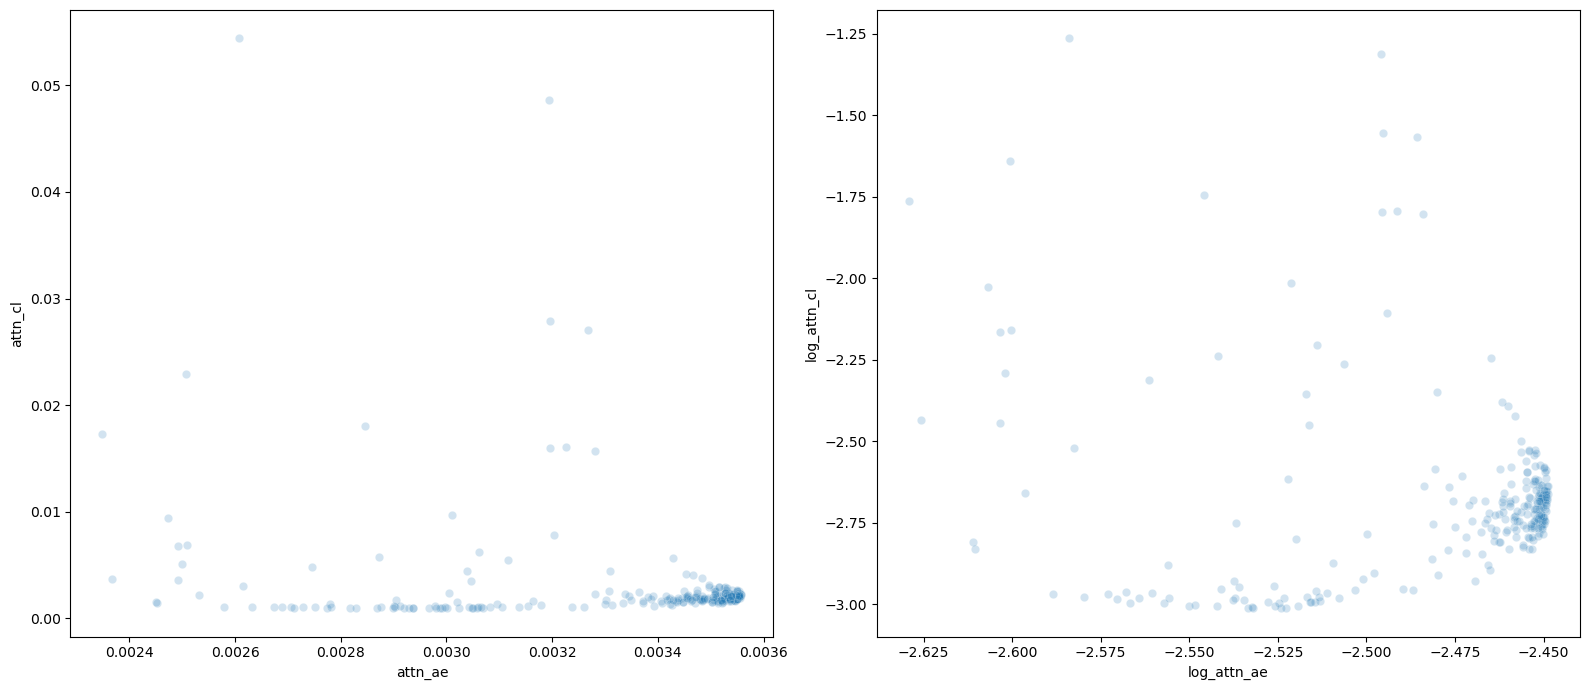

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(16,7))

sns.scatterplot(data=pathway_results, x='attn_ae', y='attn_cl', alpha=0.2, ax=ax[0])
sns.scatterplot(data=pathway_results, x='log_attn_ae', y='log_attn_cl', alpha=0.2, ax=ax[1])

plt.tight_layout()
plt.show()

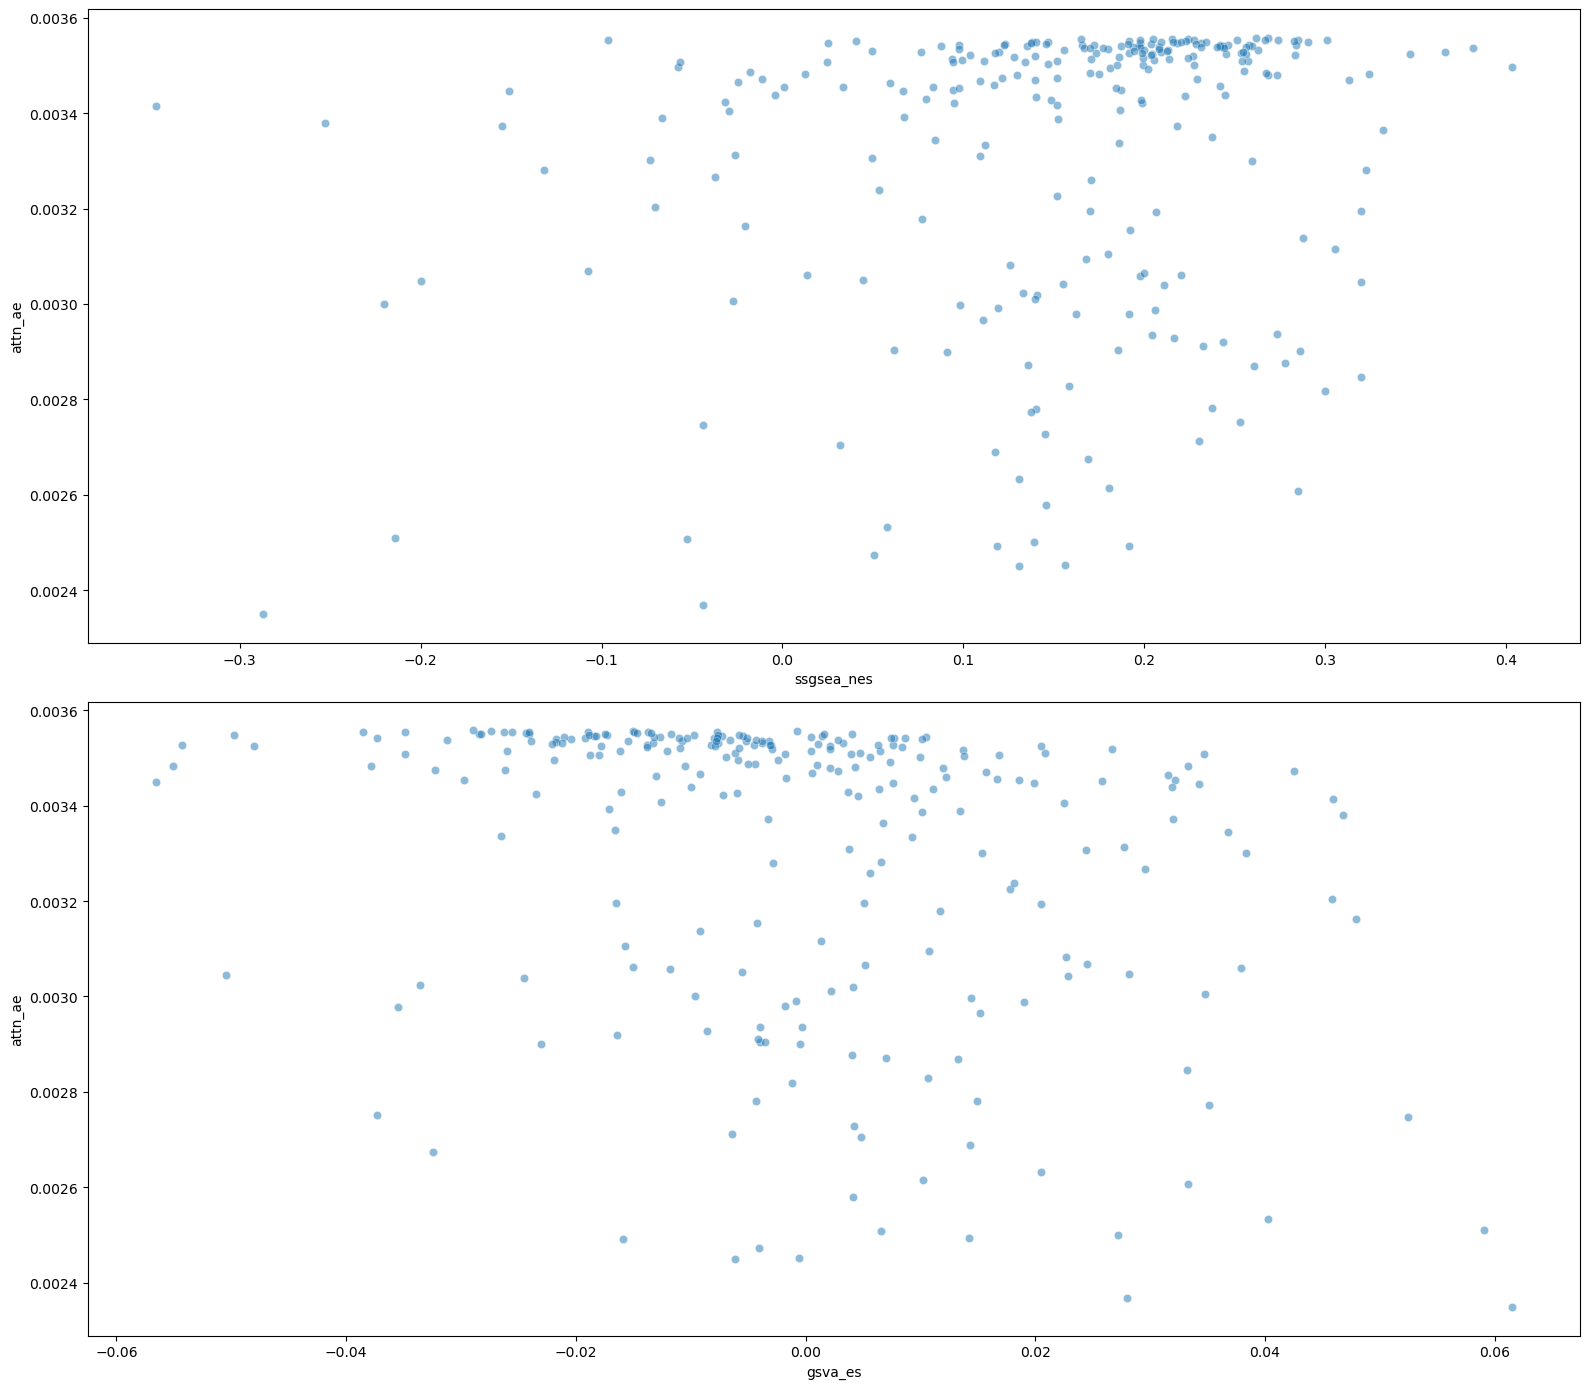

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(16,14))

sns.scatterplot(data=pathway_results, x='ssgsea_nes', y='attn_ae', alpha=0.2, ax=ax[0,0])
sns.scatterplot(data=pathway_results, x='ssgsea_nes', y='log_attn_ae', alpha=0.2, ax=ax[1,0])
sns.scatterplot(data=pathway_results, x='gsva_es', y='attn_ae', alpha=0.2, ax=ax[0,1])
sns.scatterplot(data=pathway_results, x='gsva_es', y='log_attn_ae', alpha=0.2, ax=ax[1,1])

plt.tight_layout()
plt.show()

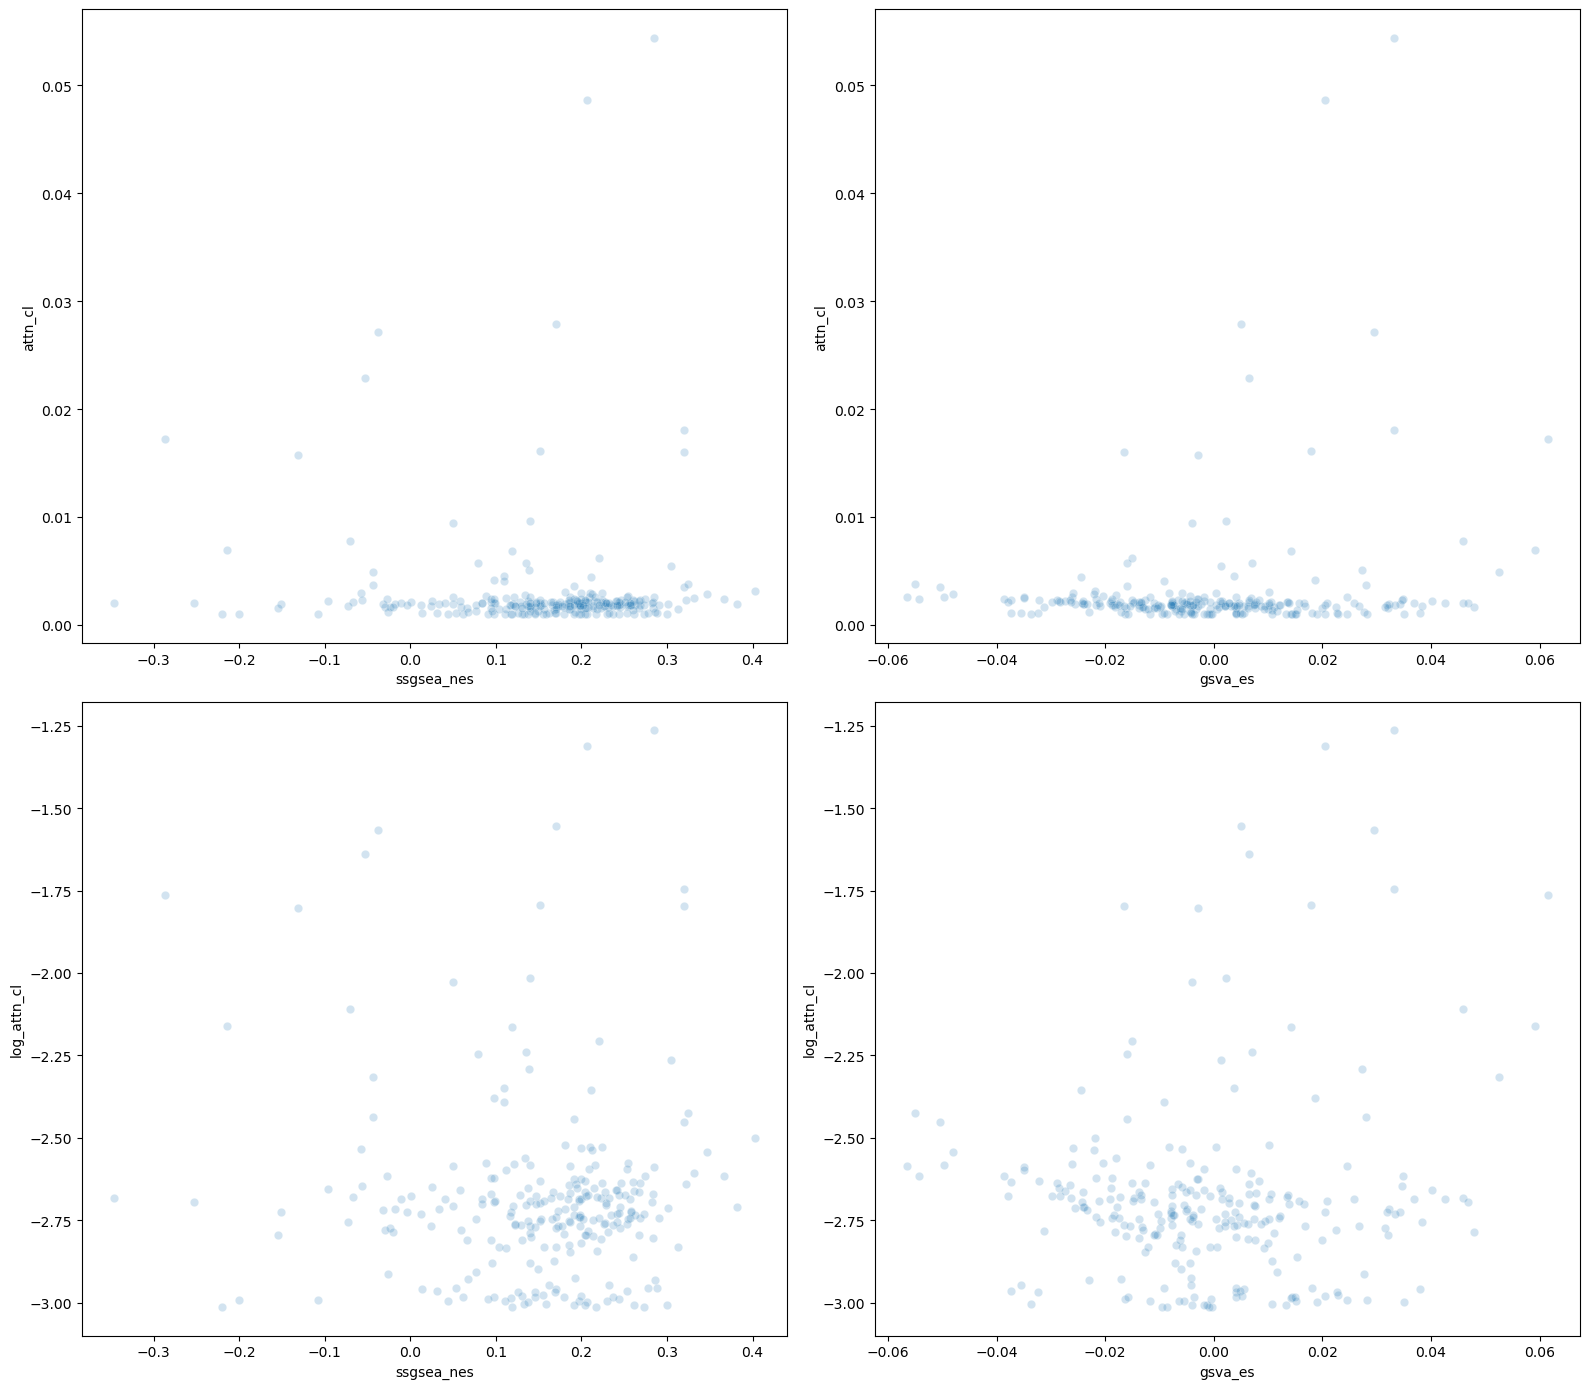

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(16,14))

sns.scatterplot(data=pathway_results, x='ssgsea_nes', y='attn_cl', alpha=0.2, ax=ax[0,0])
sns.scatterplot(data=pathway_results, x='ssgsea_nes', y='log_attn_cl', alpha=0.2, ax=ax[1,0])
sns.scatterplot(data=pathway_results, x='gsva_es', y='attn_cl', alpha=0.2, ax=ax[0,1])
sns.scatterplot(data=pathway_results, x='gsva_es', y='log_attn_cl', alpha=0.2, ax=ax[1,1])

plt.tight_layout()
plt.show()

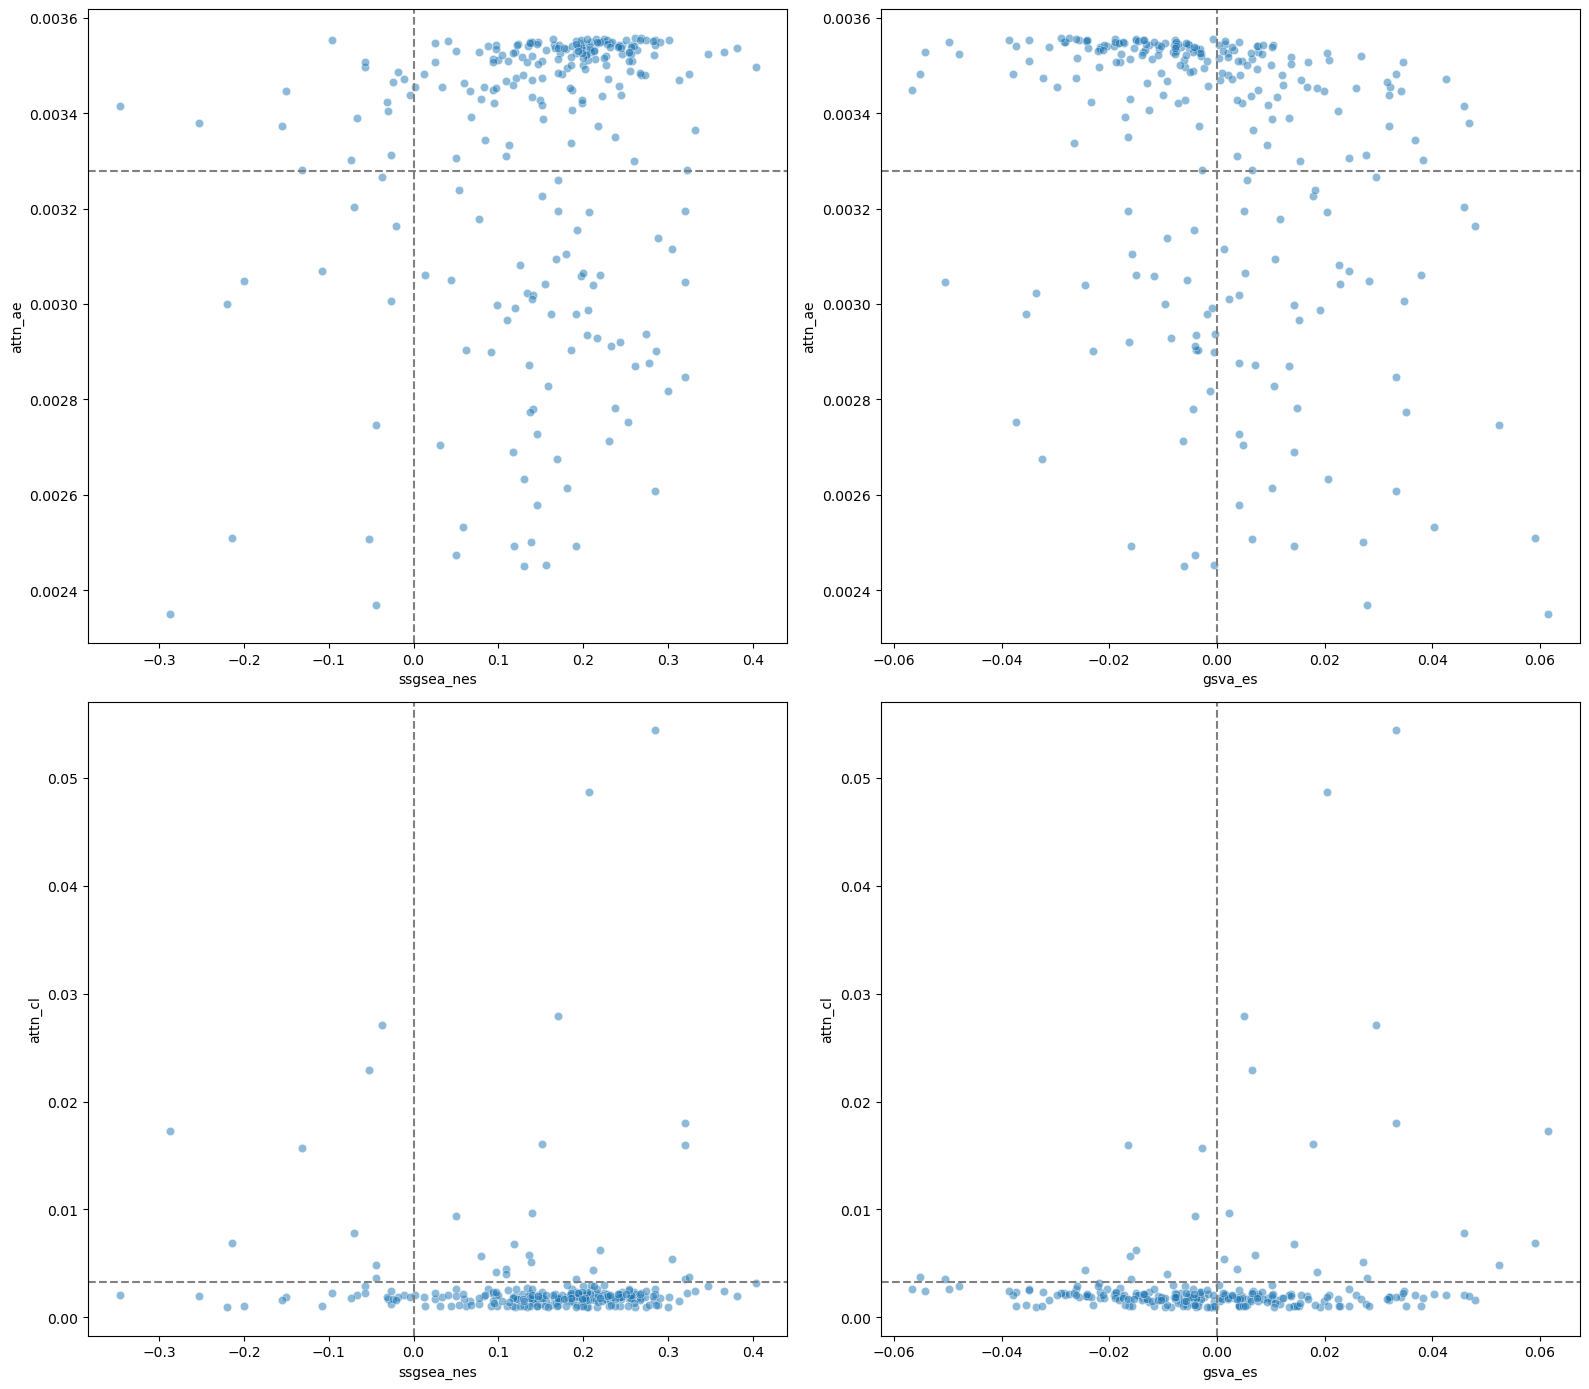

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(16,14))

def plot_scores(x,y,ax0,ax1):
    df=pathway_results
    ax[ax0,ax1].axvline(0, color='grey', linestyle='--')
    ax[ax0,ax1].axhline(1/305, color='grey', linestyle='--')
    sns.scatterplot(data=df, x=x, y=y, alpha=0.5, ax=ax[ax0,ax1])


plot_scores('ssgsea_nes', 'attn_ae', 0, 0)
plot_scores('ssgsea_nes', 'attn_cl', 1, 0)
plot_scores('gsva_es', 'attn_ae', 0, 1)
plot_scores('gsva_es', 'attn_cl', 1, 1)

# alpha = 0.5
# sns.scatterplot(data=pathway_results, x='ssgsea_nes', y='attn_ae', alpha=alpha, ax=ax[0,0])
# sns.scatterplot(data=pathway_results, x='ssgsea_nes', y='attn_cl', alpha=alpha, ax=ax[1,0])
# sns.scatterplot(data=pathway_results, x='gsva_es', y='attn_ae', alpha=alpha, ax=ax[0,1])
# sns.scatterplot(data=pathway_results, x='gsva_es', y='attn_cl', alpha=alpha, ax=ax[1,1])

plt.tight_layout()
plt.show()

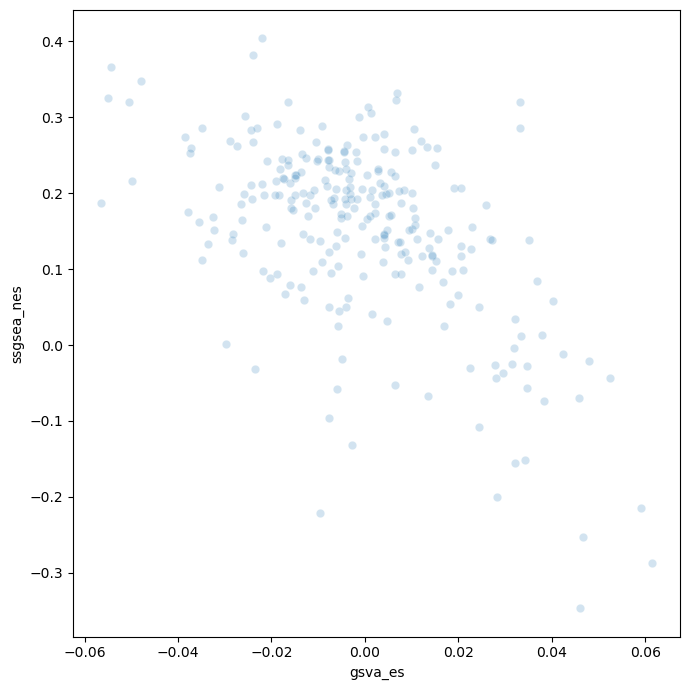

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(7,7))

sns.scatterplot(data=pathway_results, x='gsva_es', y='ssgsea_nes', alpha=0.2, ax=ax)

plt.tight_layout()
plt.show()